In [1]:
import os
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import logging

# GLOBAL CONSTANTS
PATH_TO_FIGURES = "./fig/"
FIGSIZE = (9, 6)
LEGEND_FONTSIZE = 20
LABEL_FONTSIZE = 28
hatches = ['xx', '\\\\', '//', '--', '++', '||', 'o', 'O', '.', '*']
width = 0.35  # the width of the bars
line_width = 3.5
# colors = ['#7F449B', '#009D72', '#E5A023']
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
system = ["GAE", "vSoC", "Anbox", "Redroid", "MCon"]
font = {'family': 'Arial',
        'weight': 'normal',
        'size': LABEL_FONTSIZE}

# envsetup
plt.rc('font', **font)
plt.rcParams.update({'legend.handlelength': 1.3, 'legend.borderpad': 0.25,
                     "legend.labelspacing": 0.25, "legend.handletextpad": 0.5})
plt.rcParams['hatch.linewidth'] = line_width
pd.set_option("display.max_colwidth", 5000)
pd.set_option("display.max_columns", 10000)
pd.set_option("display.max_rows", 100)
os.makedirs(PATH_TO_FIGURES, exist_ok=True)
warnings.filterwarnings('ignore')

# refresh the fonts just installed
matplotlib.font_manager._load_fontmanager(try_read_cache=False)



In [2]:
# Hardcoded final plotting data (no file read, no post-processing)
scale = [1, 2, 4, 8, 16, 32, 64]
gae = np.array([6.37445283018868, 7.150439999999999, 7.989915966386555, 10.738600961538461, 13.0])
vsoc = np.array([12.786200000000001, 12.932933333333333, 14.2071, 16.988533333333333, 19.468933333333332])
anbox = np.array([24.585899999999995, 23.913337499999994, 52.16673749999999, 84.86538749999998, 127.29808124999997, 267.32597062499997])
redroid = np.array([4.83132, 5.8614999999999995, 8.01354, 16.01086, 36.2429, 74, 371.6709907692308])
mcon = np.array([8.512220000000001, 7.950220000000001, 9.115795918367347, 9.432333333333334, 6.0434, 7.729640000000001, 14.150481481481483, 23.0])
gae_max = 12
vsoc_max = 16
anbox_max = 31
redroid_max = 39
mcon_max = 103

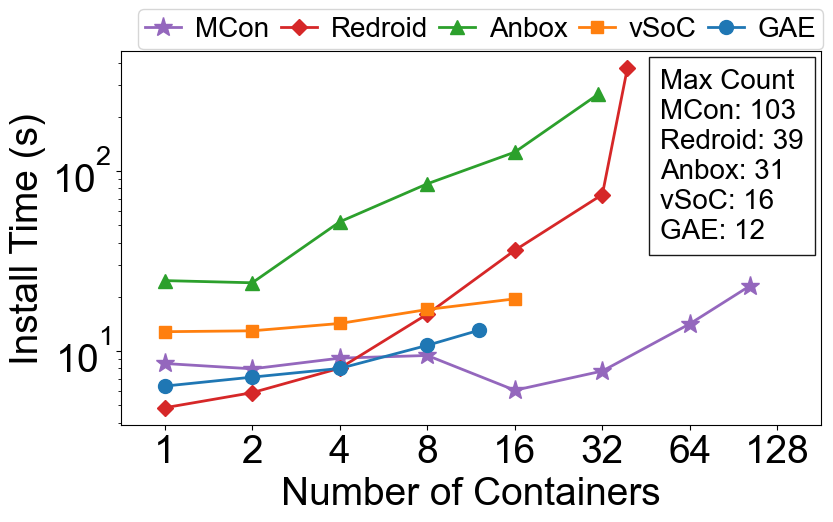

In [3]:
x_ticks = np.array([1, 2, 4, 8, 16, 32, 64, 128])
x_log = np.log2(x_ticks)

# =========================
# 自动对齐函数（核心）
# =========================
def align_to_log_axis(y, max_x):
    """
    把 y 等距映射到 [1, max_x] 的 log2 轴上
    """
    n = len(y)
    log_end = np.log2(max_x)
    x = np.linspace(0, n-2, n-1)
    # x = order[:n]
    x = np.append(x, log_end)
    return x, y

# =========================
# 生成每条曲线坐标
# =========================
x_gae, y_gae = align_to_log_axis(gae, gae_max)
x_vsoc, y_vsoc = align_to_log_axis(vsoc, vsoc_max)
x_anbox, y_anbox = align_to_log_axis(anbox, anbox_max)
x_redroid, y_redroid = align_to_log_axis(redroid, redroid_max)
x_mcon, y_mcon = align_to_log_axis(mcon, mcon_max)

# =========================
# 画图
# =========================
plt.figure(figsize=FIGSIZE)

plt.xlim(-0.5, 7.5)

plt.plot(x_mcon, y_mcon, marker="*",markersize=14, linewidth=2, label="MCon", color=colors[4])
plt.plot(x_redroid, y_redroid, marker="D", markersize=8, linewidth=2, label="Redroid", color=colors[3])
plt.plot(x_anbox, y_anbox, marker="^",markersize=10, linewidth=2, label="Anbox", color=colors[2])
plt.plot(x_vsoc, y_vsoc, marker="s", markersize=8, linewidth=2, label="vSoC", color=colors[1])
plt.plot(x_gae, y_gae, marker="o", markersize=10,linewidth=2, label="GAE", color=colors[0])


# =========================
# 坐标轴设置
# =========================
plt.xticks(x_log, x_ticks, fontsize=LABEL_FONTSIZE)
plt.xlabel("Number of Containers", fontsize=LABEL_FONTSIZE)
plt.ylabel("Install Time (s)", fontsize=LABEL_FONTSIZE)

plt.yscale("log", base=10)

proxy_i_text = (
    f"Max Count\n"
    f"MCon: {mcon_max}\n"
    f"Redroid: {redroid_max}\n"
    f"Anbox: {anbox_max}\n"
    f"vSoC: {vsoc_max}\n"    
    f"GAE: {gae_max}"
)

plt.annotate(
    proxy_i_text,
    xycoords="axes fraction",
    xy=(0.8, 0.82),             # 箭头指向 proxy_i 的中位数
    xytext=(0.77, 0.5),             # ✅ 换一个位置，避免重叠
    textcoords="axes fraction",
    # arrowprops=dict(arrowstyle="->", linewidth=1.5, color = colors[1] ),
    bbox=dict(boxstyle="square,pad=0.4", fc="white", ec="black", alpha=0.9),
    fontsize=LEGEND_FONTSIZE,
    color="black"
)

# plt.title("Container Startup Time vs. Number of Containers")
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.legend()
plt.legend(
    loc="upper left",          # 左上角对齐锚点
    ncol=5,                    # ✅ 两列排放
    # frameon=True,             # 显示边框
    bbox_to_anchor=(0.005, 1.15),  # ✅ 控制与图边框的距离（x, y）
    fontsize=20,
    # borderpad=0.6,            # 图例内容与边框的内边距
    # labelspacing=0.2,         # 每一项之间的竖直间距
    columnspacing=0.4,        # 两列之间的水平间距
    # handletextpad=0.6         # marker 与文字之间的间距
)
plt.tight_layout()

plt.savefig(PATH_TO_FIGURES + "container_install_time.pdf", format="pdf", bbox_inches="tight", pad_inches=0)
plt.show()